#  **Setup and LOAD DATA**

In [63]:
import tensorflow as tf
import os



In [64]:
import cv2

# Set the path to my dataset in kaggle
data_dir = '/kaggle/input/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset' 

# The acceptable types of images 
valid_extensions = ['.jpeg', '.jpg', '.png' ,'bmp']

#test function
def is_valid_image(file_path):
    # 1. Check if the file extension is correct
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_extensions:
        return False
        
    # try opening the image with OpenCV
    img = cv2.imread(file_path)
    if img is None:
        return False
        
    return True


In [65]:
os.listdir(data_dir)

['val', 'test', 'train']

In [66]:
#remove the bad images
for dir1 in os.listdir(data_dir):
    # print(dir1)
    for dir2 in os.listdir(os.path.join(data_dir,dir1)):
        # print(dir2)
        for img in os.listdir(os.path.join(data_dir,dir1 ,dir2)):
            full_img_path = os.path.join(data_dir, dir1, dir2, img)
            if not is_valid_image(full_img_path):
                os.remove(full_img_path)

In [67]:
import numpy as np
from matplotlib import pyplot as plt

In [68]:
#  Load the datasets

# Train
data_train = tf.keras.utils.image_dataset_from_directory(os.path.join(data_dir, 'train'))
# Validation
data_val = tf.keras.utils.image_dataset_from_directory(os.path.join(data_dir, 'val'))
# Test
data_test = tf.keras.utils.image_dataset_from_directory(os.path.join(data_dir, 'test'))

# Class names
class_names = data_train.class_names
print("\n classes are:", class_names)

Found 6800 files belonging to 2 classes.
Found 1700 files belonging to 2 classes.
Found 30 files belonging to 2 classes.

 classes are: ['NORMAL', 'PNEUMONIA']


In [69]:
data_iterator = data_train.as_numpy_iterator()

In [70]:
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x7ab11a2b8800>)

In [71]:
batch = data_iterator.next()

In [72]:
batch[1]

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 0], dtype=int32)

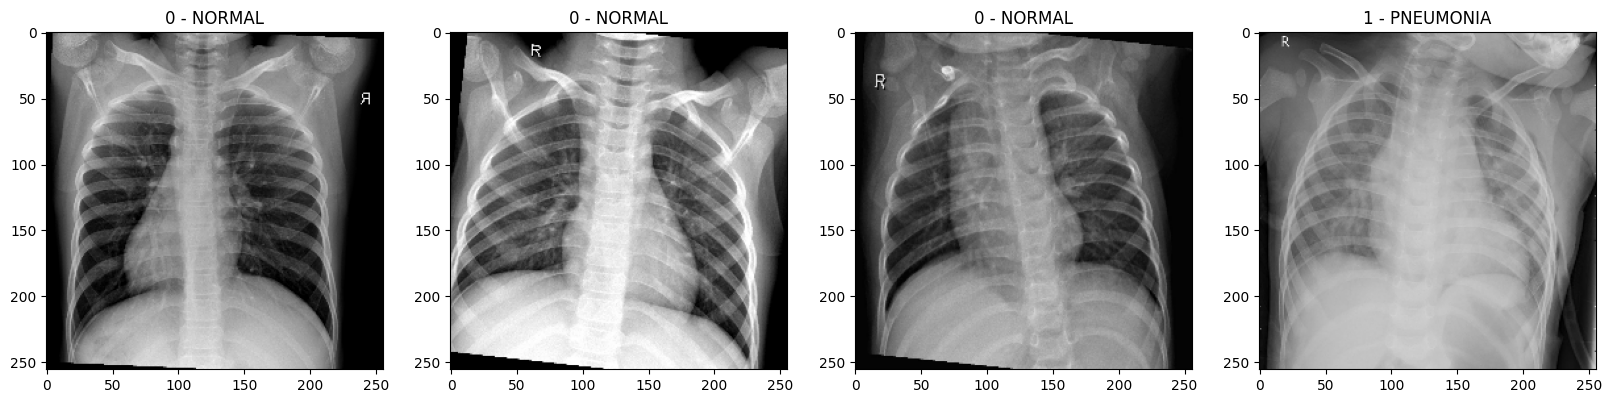

In [73]:
fig ,ax =plt.subplots(ncols=4,figsize=(20,20))
for idx , img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(f"{batch[1][idx]} - {class_names[batch[1][idx]]}")

In [74]:
# class 0 : NORMAL
# class 1 : PNEUMONIA

# **PREPROCESSING DATA**

In [75]:
# scale the data values betwen 0 and 1
Train_data = data_train.map(lambda x,y: (x/255,y))

Val_data = data_val.map(lambda x,y: (x/255,y))

Test_data = data_test.map(lambda x,y: (x/255,y))

In [76]:
# normal data min=0 and max = 255
batch[0].max()

np.float32(255.0)

In [77]:
#scaled data min=0 and max = 1
scaled_batch = Train_data.as_numpy_iterator().next()
scaled_batch[0].max()

np.float32(1.0)

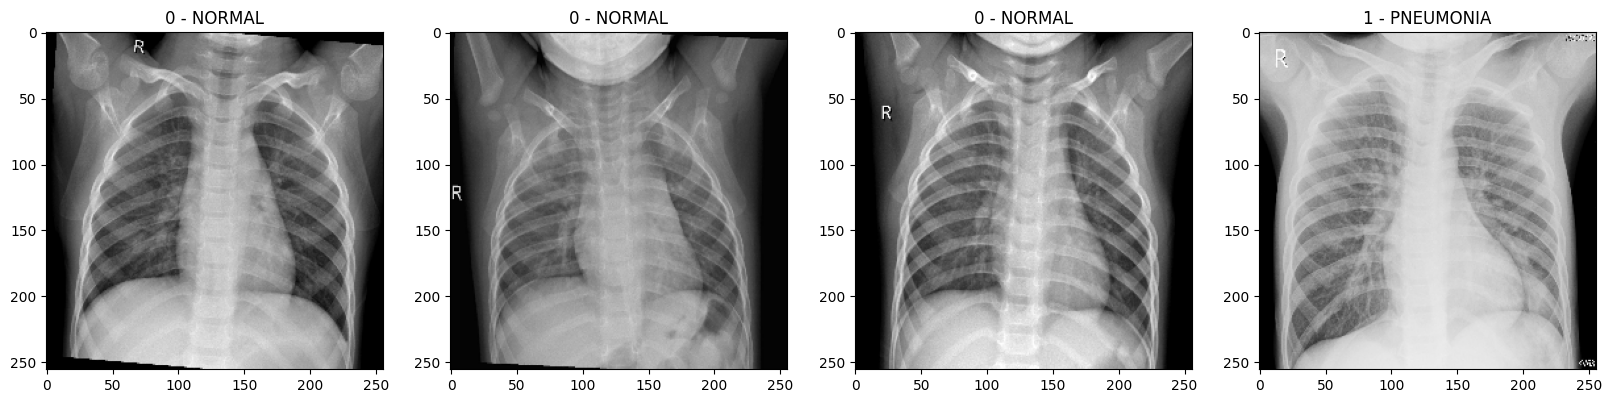

In [78]:
fig ,ax =plt.subplots(ncols=4,figsize=(20,20))
for idx , img in enumerate(scaled_batch[0][:4]):
    ax[idx].imshow(img)  # remove astype(int) because the values is betwen 0 and 1 so it gonna give a black image
    ax[idx].title.set_text(f"{batch[1][idx]} - {class_names[batch[1][idx]]}")

# **Building  the Deep Neural Network**

In [86]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Dense,GlobalAveragePooling2D, Flatten, Dropout

In [87]:
# initialation the model
model = Sequential()

model.add(Input(shape=(256, 256, 3)))

model.add(Conv2D(16,(3,3),1,activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

# model.add(Flatten())
#change flatten to globalaveragepooling2d because of overfetting
model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation='relu'))


# model.add(Dropout(0.5))
model.add(Dense(1,activation='sigmoid'))

In [88]:
# compile the model using adam
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [89]:
# the model summary
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_23 (Conv2D)              │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,321 (55.94 KB)

 Trainable params: 14,321 (55.94 KB)

 Non-trainable params: 0 (0.00 B)

In [83]:
# Create the logs folder
log_dir = "/kaggle/working/logs"
os.makedirs(log_dir, exist_ok=True)

In [90]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir)

In [91]:
hist =model.fit(Train_data, epochs=20 , validation_data=Val_data ,callbacks=[tensorboard_callback])

Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 29s 123ms/step - accuracy: 0.5668 - loss: 0.6754 - val_accuracy: 0.8165 - val_loss: 0.3996
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - accuracy: 0.8337 - loss: 0.3968 - val_accuracy: 0.8094 - val_loss: 0.3944
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - accuracy: 0.8656 - loss: 0.3224 - val_accuracy: 0.8412 - val_loss: 0.3417
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - accuracy: 0.8762 - loss: 0.2731 - val_accuracy: 0.9012 - val_loss: 0.2477
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - accuracy: 0.8840 - loss: 0.2639 - val_accuracy: 0.8912 - val_loss: 0.2428
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - accuracy: 0.8943 - loss: 0.2404 - val_accuracy: 0.8976 - val_loss: 0.2314
Epoch 7/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 25s 117ms/step - accuracy: 0.9002 - loss: 0.2342 - val_accuracy: 0.9012 - val_loss: 0.2457
Epoch 8/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 25s 118ms/step - accuracy: 0.8989 - loss: 0

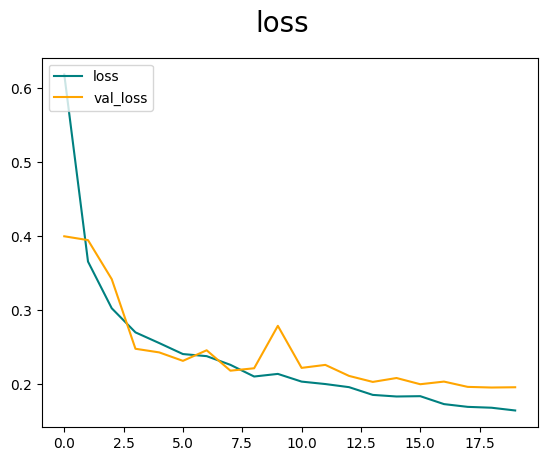

In [92]:
fig = plt.figure
plt.plot(hist.history['loss'],color='teal', label='loss')
plt.plot(hist.history['val_loss'],color='orange', label='val_loss')
plt.suptitle('loss',fontsize=20)
plt.legend(loc='upper left')
plt.show()

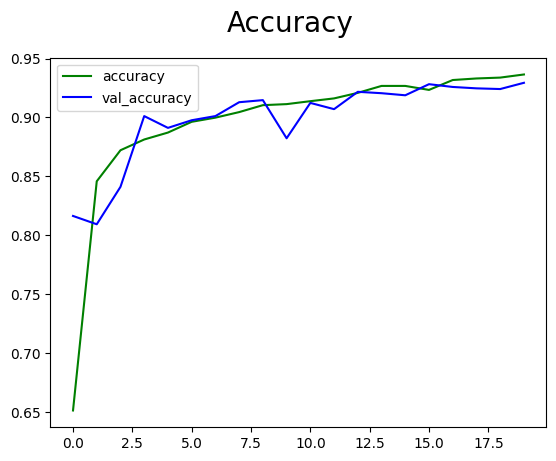

In [94]:
fig = plt.figure
plt.plot(hist.history['accuracy'],color='green', label='accuracy')
plt.plot(hist.history['val_accuracy'],color='blue', label='val_accuracy')
plt.suptitle('Accuracy',fontsize=20)
plt.legend(loc='upper left')
plt.show()

# **Evaluate Performance**

In [95]:
from tensorflow.keras.metrics import Precision , Recall ,BinaryAccuracy

In [96]:
pre = Precision()
Rec = Recall()
acc = BinaryAccuracy()

In [98]:
for batch in Test_data.as_numpy_iterator():
    X , y = batch
    y_predict =model.predict(X)
    pre.update_state(y,y_predict)
    Rec.update_state(y,y_predict)
    acc.update_state(y,y_predict)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 825ms/step


In [102]:
print(f"Precision : {pre.result().numpy()}")
print(f"Recall : {Rec.result().numpy()}")
print(f"Accuracy : {acc.result().numpy()}")

Precision : 0.7894737124443054
Recall : 1.0
Accuracy : 0.8666666746139526


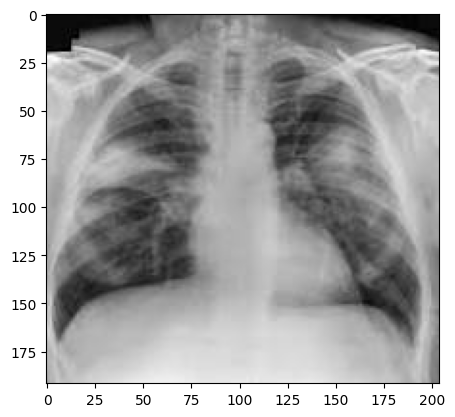

In [110]:
# test with a random image from google of a Pneumonia scan
Pneumonia_test_image = cv2.imread('/kaggle/input/datasets/mohamedafkir90/test-image-pneumonia/pneumoniaTest.png')
plt.imshow(Pneumonia_test_image)
plt.show()

In [111]:
resized_image = tf.image.resize(Pneumonia_test_image,(256,256))

In [112]:
yhat_test = model.predict(np.expand_dims(resized_image/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


In [113]:
if yhat_test<0.5:
    print(f"Normal , {yhat_test}")
else :
    print(f"Pneumonia , {yhat_test}")

Pneumonia , [[0.623773]]


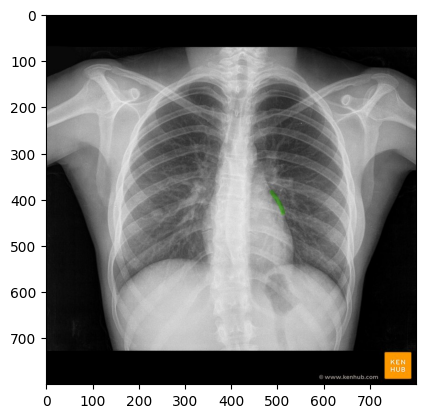

In [114]:
# test with a random image from google of a healty scan
healty_test_image = cv2.imread('/kaggle/input/datasets/mohamedafkir90/healty/healthy.png')
plt.imshow(healty_test_image)
plt.show()

In [115]:
resized_image = tf.image.resize(healty_test_image,(256,256))
yhat_test = model.predict(np.expand_dims(resized_image/255,0))

if yhat_test<0.5:
    print(f"Normal , {yhat_test}")
else :
    print(f"Pneumonia , {yhat_test}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Normal , [[1.3718819e-06]]


# **Finish and Save the Model**

In [116]:
# Create the models version folder
models_dir = "/kaggle/working/models"
os.makedirs(models_dir, exist_ok=True)

In [118]:
from tensorflow.keras.models import load_model
# save the model 
model.save(os.path.join(models_dir,'Pneumonia_check_model_01.keras'))

In [119]:
# test the saved model
saved_model = load_model(os.path.join(models_dir,'Pneumonia_check_model_01.keras'))

#test with normal
yhat_test = saved_model.predict(np.expand_dims(resized_image/255,0))

if yhat_test<0.5:
    print(f"Normal , {yhat_test}")
else :
    print(f"Pneumonia , {yhat_test}")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 12 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step
Normal , [[1.3718819e-06]]
